# Lesson 2: Advanced Data Warehousing & Multidimensional Analysis

## 🎯 Objective
In this lab, we transition from simple data manipulation to **Architectural Thinking**. We will simulate a real-world enterprise environment for a global electronics retailer, **"ElectroGlobal Corp."**

### Key Concepts:
1.  **Data Lake (Schema-on-Read)**: Storing raw, heterogeneous data (JSON/CSV) with intentional messiness.
2.  **Data Integration & ETL**: Merging, cleaning, and transforming disparate data sources.
3.  **Data Warehouse (Schema-on-Write)**: Organizing cleaned data into **Star** and **Snowflake** schemas.
4.  **OLAP Operations in Depth**: Master **Slice, Dice, Roll-up, Drill-down, Pivot, and Top-N Analysis**.
5.  **The Data Cube**: Visualizing the **Lattice of Cuboids** (Apex to Base) using Plotly 3D.
6.  **Advanced Analysis**: Visualize the **Curse of Dimensionality** and use **PCA** (Before & After).
---

In [1]:
import pandas as pd
import numpy as np
import json
import os
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("[SYSTEM] Environment ready. All libraries imported.")

[SYSTEM] Environment ready. All libraries imported.


## Part 1: The Messy Data Lake Simulation (Schema-on-Read)

Imagine our retailer receives raw logs from various systems. This is our **Data Lake**. It's messy, highly unstructured, and relies on **Schema-on-Read** (meaning we have to figure out the structure of the data at the exact moment we query it, rather than enforcing rules before saving it).

### 1.1 Generating Intentional Noise & Type Mix-ups
We will create two separate raw files:
1.  **Source A (JSON)**: Nested transactions with type mix-ups (strings in price columns) and duplicates.
2.  **Source B (CSV)**: Flat logs with outliers (negative prices) and missing values (nulls).

In [2]:
os.makedirs('data_lake', exist_ok=True)
np.random.seed(42)
num_rows = 5000

products = ["Laptop", "Mouse", "Phone", "TV", "Cables", "Monitor", "Keyboard"]
stores = ["London-01", "Paris-05", "NYC-02", "Tokyo-04", "Berlin-03"]

# 1. SOURCE A: Nested JSON (e.g., Web API) with Noise
json_data = []
for i in range(num_rows):
    txn_id = f"JSON_{i:05d}"
    
    price = np.random.uniform(50, 1500)
    if np.random.rand() < 0.05:
        price = "REFUNDED" if np.random.rand() > 0.5 else "$PENDING" # Type mixup
        
    json_data.append({
        "transaction_id": txn_id,
        "meta_info": {
            "timestamp": (pd.to_datetime('2023-01-01') + pd.Timedelta(days=np.random.randint(0, 180))).strftime('%Y-%m-%d'),
            "store_id": np.random.choice(stores + [None, "UNKNOWN"])
        },
        "basket": [{"product": np.random.choice(products), "quantity": np.random.randint(1, 5), "unit_price": price}]
    })

json_data = json_data + json_data[:100] # Inject duplicates
with open('data_lake/source_a_transactions.json', 'w') as f:
    json.dump(json_data, f)

# 2. SOURCE B: Flat CSV (e.g., POS system) with Noise
csv_rows = []
for i in range(num_rows):
    txn_id = f"CSV_{i:05d}"
    qty = np.random.randint(1, 10)
    if np.random.rand() < 0.05:
        qty = "QTY_ERR" if np.random.rand() > 0.5 else None # Missing Values & Type mixup
        
    csv_rows.append({
        "LOG_ID": txn_id,
        "EVENT_TIME": (pd.to_datetime('2023-07-01') + pd.Timedelta(days=np.random.randint(0, 180))).strftime('%Y-%m-%d'),
        "LOCATION": np.random.choice(stores),
        "ITEM": np.random.choice(products),
        "UNITS": qty,
        "PRICE_PER_UNIT": np.random.uniform(-500, 2000) # Negative price outliers
    })

pd.DataFrame(csv_rows).to_csv('data_lake/source_b_logs.csv', index=False)
print("[SYSTEM] Data Lake initialized with messy JSON and CSV files.")

[SYSTEM] Data Lake initialized with messy JSON and CSV files.


## Part 2: Exploratory Data Analysis (EDA)

Let's explore both datasets using `.info()`. Notice how the intentional noise caused `Quantity` and `Price` to be read as `object` (string) types instead of numbers! This is a classic symptom of poor data quality in a Data Lake.

In [3]:
# --- EDA for Source A (JSON) ---
with open('data_lake/source_a_transactions.json', 'r') as f:
    raw_json = json.load(f)

df_json = pd.json_normalize(
    raw_json, 
    record_path=['basket'], 
    meta=[['meta_info', 'timestamp'], ['meta_info', 'store_id'], 'transaction_id']
)

print("--- Source A (JSON) EDA ---")
print(df_json.info())

# --- EDA for Source B (CSV) ---
df_csv = pd.read_csv('data_lake/source_b_logs.csv')
print("\n--- Source B (CSV) EDA ---")
print(df_csv.info())

--- Source A (JSON) EDA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product              5100 non-null   object
 1   quantity             5100 non-null   int64 
 2   unit_price           5100 non-null   object
 3   meta_info.timestamp  5100 non-null   object
 4   meta_info.store_id   4353 non-null   object
 5   transaction_id       5100 non-null   object
dtypes: int64(1), object(5)
memory usage: 239.2+ KB
None

--- Source B (CSV) EDA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LOG_ID          5000 non-null   object 
 1   EVENT_TIME      5000 non-null   object 
 2   LOCATION        5000 non-null   object 
 3   ITEM            5000 non-null   object 
 4   UNITS   

### 👩‍💻 Student Exercise 1: Deep Dive EDA & Visualization
The basic `.info()` above shows us that there are type errors and missing values. Let's find exactly what is causing them.

**Your Task:**
1.  **Analyze JSON Errors**: Find the unique string values in the JSON `unit_price` column that are causing the type error.
2.  **Visualize CSV Outliers**: Plot a boxplot or histogram of the CSV `PRICE_PER_UNIT` column to visualize the negative price outliers.
3.  **Detect Nulls**: Print out the exact count of missing (`NaN`) values in the CSV `UNITS` column.

In [4]:
# [STUDENT WORK AREA] - Write your EDA code here!

# 1. Find unique string values in JSON 'unit_price':

# 2. Boxplot of CSV 'PRICE_PER_UNIT' (Use sns.boxplot):

# 3. Count NaN values in CSV 'UNITS':


## Part 3: Data Integration, Cleaning & Warehousing (The ETL Pipeline)

To make this data useful for analytics, we must move it to a **Data Warehouse**. This process is known as ETL (Extract, Transform, Load):
1.  **Integration (Extract & Load)**: Renaming columns to a single standard schema and concatenating disparate systems.
2.  **The Quality Gate (Transform)**: Fixing data types, dropping nulls/duplicates, and removing negative price errors.
3.  **Schema-on-Write**: Enforcing a strict schema (**Star Schema**) so business analysts can trust the data.

In [5]:
# --- 1. INTEGRATION (Standardization) ---
df_json.columns = ['Product', 'Quantity', 'Price', 'Date', 'Store', 'TXN_ID']
df_csv.columns = ['TXN_ID', 'Date', 'Store', 'Product', 'Quantity', 'Price']
integrated_df = pd.concat([df_json, df_csv], ignore_index=True)

# --- 2. THE DATA QUALITY GATE (Cleaning & Transformation) ---
before = len(integrated_df)

# Fix Type Mix-ups: Coerce errors to NaN
integrated_df['Quantity'] = pd.to_numeric(integrated_df['Quantity'], errors='coerce')
integrated_df['Price'] = pd.to_numeric(integrated_df['Price'], errors='coerce')

# Remove duplicates
integrated_df = integrated_df.drop_duplicates()

# Filter valid rows
integrated_df = integrated_df.dropna(subset=['Store', 'Quantity', 'Price'])
integrated_df = integrated_df[integrated_df['Store'] != 'UNKNOWN']
integrated_df = integrated_df[integrated_df['Price'] > 0]

# Feature Engineering
integrated_df['Date'] = pd.to_datetime(integrated_df['Date'])
integrated_df['Revenue'] = integrated_df['Quantity'] * integrated_df['Price']

after = len(integrated_df)
print(f"[ETL] Cleaned {before - after} noisy records. Trusted rows: {after}")

[ETL] Cleaned 2945 noisy records. Trusted rows: 7155


### 👩‍💻 Student Exercise 2: Advanced Cleaning (Imputation & Encoding)
In the professional pipeline above, we simply dropped rows with missing values (`dropna`). In many real-world scenarios, dropping data means losing valuable information. 

**Your Task:**
1.  **Imputation**: Imagine we didn't drop the `NaN` values. Write the code that *would* fill any `NaN` values in the `Quantity` column with the **median** value of that column.
2.  **Encoding**: Machine Learning models require numerical inputs, not text. Use pandas to create a new column called `Store_Code` in `integrated_df` that converts the string `Store` names into integer categorical codes (Hint: use `.astype('category').cat.codes`).

In [6]:
# [STUDENT WORK AREA] - Write your Imputation and Encoding code here!

# 1. Impute Quantity with Median:
# integrated_df['Quantity'] = ... 

# 2. Encode Store into 'Store_Code':
# integrated_df['Store_Code'] = ... 


### 3.1 Warehouse Architecture (Star vs. Snowflake)

| Schema | Structure | Pros | Use Case |
| :--- | :--- | :--- | :--- |
| **Star Schema** | One Fact, multiple flat Dimensions. | Fastest Querying, Simple. | Most BI tools (Retail, Sales). |
| **Snowflake Schema** | Dimensions are **Normalized** (split into sub-tables). | Less storage, strict data integrity. | Complex ERP, Insurance, Large Hierarchies. |

Let's visually plot the difference between a Star and Snowflake schema to understand the architecture we are building.

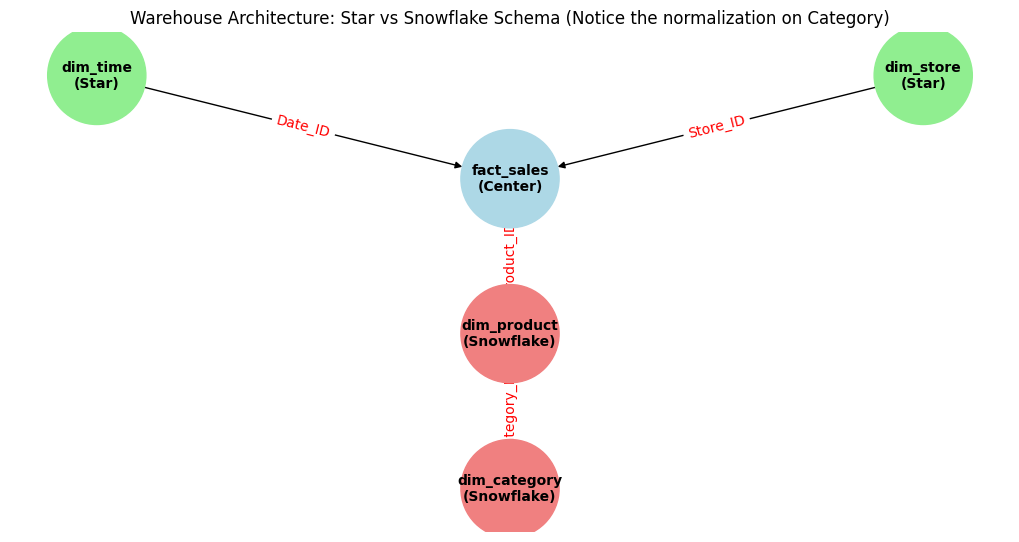

In [7]:
plt.figure(figsize=(10, 5))
G = nx.DiGraph()

# Add nodes (Tables)
G.add_node("fact_sales\n(Center)", pos=(0, 0), color='lightblue')
G.add_node("dim_time\n(Star)", pos=(-2, 1), color='lightgreen')
G.add_node("dim_store\n(Star)", pos=(2, 1), color='lightgreen')
G.add_node("dim_product\n(Snowflake)", pos=(0, -1.5), color='lightcoral')
G.add_node("dim_category\n(Snowflake)", pos=(0, -3), color='lightcoral')

# Add edges (Relationships)
G.add_edge("dim_time\n(Star)", "fact_sales\n(Center)", label="Date_ID")
G.add_edge("dim_store\n(Star)", "fact_sales\n(Center)", label="Store_ID")
G.add_edge("dim_product\n(Snowflake)", "fact_sales\n(Center)", label="Product_ID")
G.add_edge("dim_category\n(Snowflake)", "dim_product\n(Snowflake)", label="Category_ID")

pos = nx.get_node_attributes(G, 'pos')
colors = [node[1]['color'] for node in G.nodes(data=True)]

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=5000, font_size=10, font_weight='bold', arrows=True)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Warehouse Architecture: Star vs Snowflake Schema (Notice the normalization on Category)")
plt.show()

We will create a **Fact Table** (Sales) and a **Time Dimension** (Star Schema). Then we will create a **Product Dimension** that contains `Category`, showing how a Snowflake schema branches out to allow for specialized Roll-ups.

In [8]:
# --- 3. SCHEMA-ON-WRITE: Star Schema Creation ---
dim_time = pd.DataFrame({
    'Date': integrated_df['Date'].unique(),
    'Year': pd.to_datetime(integrated_df['Date'].unique()).year,
    'Quarter': 'Q' + pd.to_datetime(integrated_df['Date'].unique()).quarter.astype(str),
    'Month': pd.to_datetime(integrated_df['Date'].unique()).month_name()
})

fact_sales = integrated_df[['TXN_ID', 'Product', 'Store', 'Date', 'Revenue', 'Quantity']]

# --- SNOWFLAKE EXTENSION ---
dim_product = pd.DataFrame({
    'Product': products,
    'Category': ['Electronics', 'Peripherals', 'Mobile', 'Entertainment', 'Accessories', 'Electronics', 'Peripherals']
})

print("\n--- Demonstrating the Snowflake Dimension (dim_product) ---")
print(dim_product.head())

# Persistent Storage
os.makedirs('data_warehouse', exist_ok=True)
fact_sales.to_csv('data_warehouse/fact_sales.csv', index=False)
dim_time.to_csv('data_warehouse/dim_time.csv', index=False)

print("\n[SYSTEM] Warehouse Architectures (Fact, Dim_Time, Dim_Product) provisioned.")


--- Demonstrating the Snowflake Dimension (dim_product) ---
  Product       Category
0  Laptop    Electronics
1   Mouse    Peripherals
2   Phone         Mobile
3      TV  Entertainment
4  Cables    Accessories

[SYSTEM] Warehouse Architectures (Fact, Dim_Time, Dim_Product) provisioned.


## Part 4: The Data Cube & Lattice of Cuboids

A **Data Cube** is a collection of smaller cubes, called **Cuboids**.
-   **Apex Cuboid (Level 0)**: Total aggregation across all dimensions.
-   **Intermediate Cuboids**: Sub-totals (e.g., Sales by Quarter and Store).
-   **Base Cuboid (Level n)**: The most granular level of the cube.

To build our complete Data Cube, we will merge the `fact_sales` with BOTH `dim_time` and our Snowflake dimension `dim_product`.

In [9]:
# Merge Fact with Star and Snowflake Dimensions
dw_df = pd.merge(fact_sales, dim_time, on='Date')
dw_df = pd.merge(dw_df, dim_product, on='Product')  # Bringing in the Snowflake 'Category'

apex_cuboid = dw_df['Revenue'].sum()
base_cuboid = dw_df.groupby(['Date', 'Store', 'Product', 'Category'])['Revenue'].sum()

print(f"Apex Cuboid (Grand Total): ${apex_cuboid:,.2f}")
print("\nBase Cuboid (Granular Level):")
print(base_cuboid.head())

Apex Cuboid (Grand Total): $25,504,585.19

Base Cuboid (Granular Level):
Date        Store      Product   Category   
2023-01-01  Berlin-03  Keyboard  Peripherals    2585.523814
                       Monitor   Electronics    1175.004345
            London-01  Keyboard  Peripherals    2363.042150
                       Laptop    Electronics    3240.589563
                       Monitor   Electronics     955.286513
Name: Revenue, dtype: float64


### 4.1 Visualizing the Data Cube (Plotly 3D)
We can visualize the intermediate cuboids in a 3D space using Plotly, representing Store, Product, and Time as the three axes. This provides an excellent visual representation of the Lattice of Cuboids.

In [10]:
# To visualize a 3D cube, we group by 3 dimensions: Store, Product, and Quarter
cube_3d = dw_df.groupby(['Store', 'Product', 'Quarter'])['Revenue'].sum().reset_index()

fig = px.scatter_3d(
    cube_3d, 
    x='Store', 
    y='Product', 
    z='Quarter',
    size='Revenue', 
    color='Revenue',
    title="3D Visualization of the Data Cube (Intermediate Cuboids)",
    opacity=0.8,
    color_continuous_scale='Viridis'
)
fig.show()

## Part 5: OLAP Operations (Multidimensional Analysis)

### 5.1 Slice & Dice (The Surgical Tools)
-   **Slice**: A selection on *one* dimension (e.g., Only 'Laptop' sales). This reduces the dimensionality of the cube by 1.
-   **Dice**: A sub-cube selecting *multiple* dimensions (e.g., 'Laptop' in 'London' during 'Q1'). This returns a smaller sub-cube of the original.

In [11]:
# SLICE: Look at only one product across all time and space
slice_laptop = dw_df[dw_df['Product'] == 'Laptop']

# DICE: Look at a specific intersection
dice_london_q1_laptops = dw_df[
    (dw_df['Store'].str.contains('London')) & 
    (dw_df['Quarter'] == 'Q1') & 
    (dw_df['Product'] == 'Laptop')
]

print(f"Slice (Laptops) Total Revenue: ${slice_laptop['Revenue'].sum():,.2f}")
print(f"Dice (London, Q1, Laptops) Revenue: ${dice_london_q1_laptops['Revenue'].sum():,.2f}")

Slice (Laptops) Total Revenue: $3,691,236.15
Dice (London, Q1, Laptops) Revenue: $107,699.91


### 5.2 Roll-up & Drill-down (The Zoom Tools)
- **Roll-up**: Aggregates data by moving **UP** a hierarchy (e.g., Month -> Quarter, or Product -> Category). It summarizes granular data into a higher-level view.
- **Drill-down**: Breaks down data by moving **DOWN** a hierarchy (e.g., Quarter -> Month). It reveals the granular details hidden within an aggregate.

The **`groupby()`** function with multiple columns natively creates the Data Cube. Let's compare a Snowflake Roll-up (Product -> Category) with a Drill-down (Monthly).

In [12]:
# Creating a Hierarchical Data Cube using MultiIndex
cube = dw_df.groupby(['Year', 'Quarter', 'Month', 'Store', 'Category', 'Product'])['Revenue'].sum()

# ROLL-UP (SNOWFLAKE): Move from specific Products up to the normalized 'Category' level
rollup_category = cube.groupby(level=['Year', 'Quarter', 'Store', 'Category']).sum().reset_index()
print("--- Snowflake Roll-up: Quarterly Sales by Store and Category ---")
print(rollup_category.head(10))

# DRILL-DOWN: Move from a high level down to specific months for Q1
drilldown_q1 = cube.loc[2023, 'Q1'].reset_index()
print("\n--- Drill-down: Q1 Broken down by Month, Store, Category, and Product ---")
print(drilldown_q1.head(10))

# Visualizing the Drill-down
fig_drill = px.bar(drilldown_q1, x='Month', y='Revenue', color='Product', facet_col='Store', 
                   title="Drill-down: Q1 Revenue Broken Down by Month and Product across Stores")
fig_drill.show()

--- Snowflake Roll-up: Quarterly Sales by Store and Category ---
   Year Quarter      Store       Category        Revenue
0  2023      Q1  Berlin-03    Accessories   65553.246382
1  2023      Q1  Berlin-03    Electronics  189128.167150
2  2023      Q1  Berlin-03  Entertainment   99209.234436
3  2023      Q1  Berlin-03         Mobile   55383.282184
4  2023      Q1  Berlin-03    Peripherals  175273.913275
5  2023      Q1  London-01    Accessories  103074.582139
6  2023      Q1  London-01    Electronics  231465.165859
7  2023      Q1  London-01  Entertainment   69849.119015
8  2023      Q1  London-01         Mobile   69020.124218
9  2023      Q1  London-01    Peripherals  131824.614562

--- Drill-down: Q1 Broken down by Month, Store, Category, and Product ---
      Month      Store       Category   Product       Revenue
0  February  Berlin-03    Accessories    Cables  14169.631206
1  February  Berlin-03    Electronics    Laptop  38798.352656
2  February  Berlin-03    Electronics   Monitor

### 5.3 Pivot (The Perspective Tool)
Pivoting rotates the data axes to view it from a different perspective (like in BI tools). By adding `margins=True`, we can see how the Apex (Grand Total) is formed from the cross-tabulation.

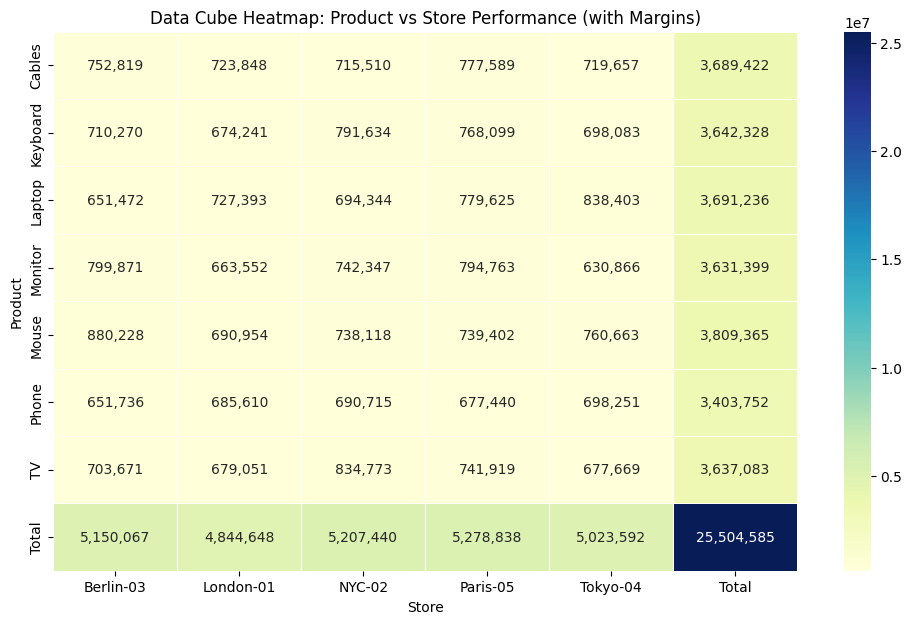

In [13]:
# Pivot with margins to show Roll-up to Apex
pivot_table = dw_df.pivot_table(values='Revenue', index='Product', columns='Store', aggfunc='sum', margins=True, margins_name='Total')

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_table, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=.5)
plt.title("Data Cube Heatmap: Product vs Store Performance (with Margins)")
plt.show()

### 5.4 Top-N Analysis (Ranking)
A very common OLAP pattern is finding the top performing entities across a specific dimension. Let's find the Top 3 Stores by total revenue.

In [14]:
top_stores = dw_df.groupby('Store')['Revenue'].sum().nlargest(3).reset_index()

fig_top = px.bar(top_stores, x='Store', y='Revenue', color='Store', text='Revenue',
                 title="Top 3 Stores by Total Revenue (Top-N Analysis)")
fig_top.update_traces(texttemplate='%{text:$.2s}', textposition='outside')
fig_top.show()

### 👩‍💻 Student Exercise 3: Your Turn to Query the Cube
Test your OLAP skills by writing the code for the following multidimensional operations:

**Your Task:**
1.  **Dice**: Find the total sum of `Revenue` specifically for **'Monitor'** sales in **'Berlin-03'** during **'Q2'**.
2.  **Top-N**: Find the Top 2 best-selling `Product` categories by **Quantity** (not Revenue) in the entire dataset.

In [15]:
# [STUDENT WORK AREA] - Write your OLAP queries here!

# 1. Dice Query (Monitor + Berlin-03 + Q2):

# 2. Top-N Query by Quantity:


## Part 6: The Algorithmic Concept - Curse of Dimensionality
As we add dimensions, the "Data Cube" grows exponentially, and most cells remain empty (sparse). Highly sparse cubes lead to enormous memory consumption and slow query performance, which is why real-world warehouses pre-compute and compress specific cuboids rather than calculating everything on the fly.

In [16]:
total_possible = len(dw_df['Product'].unique()) * len(dw_df['Store'].unique()) * len(dw_df['Quarter'].unique())
actual_data = len(dw_df.groupby(['Product', 'Store', 'Quarter']))
sparsity = (1 - (actual_data / total_possible)) * 100

print(f"Total Possible Cube Cells: {total_possible}")
print(f"Actual Data Points: {actual_data}")
print(f"Cube Sparsity: {sparsity:.2f}%")

Total Possible Cube Cells: 140
Actual Data Points: 140
Cube Sparsity: 0.00%


## Part 7: Dimensionality Reduction (PCA)
To combat high dimensionality and extract meaningful variance for Machine Learning models, we use **PCA (Principal Component Analysis)** to mathematically compress features into independent "Principal Components". This removes noise while preserving the underlying structure of the data.

### 7.1 Before PCA: High Dimensional Space
Visualizing the raw dimensions (Quantity, Product, Store) before compression.

In [17]:
pca_df = dw_df.copy()
pca_df['Prod_Enc'] = pca_df['Product'].astype('category').cat.codes
pca_df['Store_Enc'] = pca_df['Store'].astype('category').cat.codes

# Plot BEFORE PCA (High Dimensional space visualized in 3D)
fig_before = px.scatter_3d(
    pca_df, 
    x='Quantity', 
    y='Prod_Enc', 
    z='Store_Enc',
    color='Revenue',
    title="Before PCA: High-Dimensional Data (Visualizing 4 Dimensions)",
    labels={'Prod_Enc': 'Product Code', 'Store_Enc': 'Store Code'},
    opacity=0.6,
    color_continuous_scale='Plasma'
)
fig_before.show()

### 7.2 After PCA: Compressed 2D Space
We reduce the highly sparse, multi-dimensional data into exactly 2 Principal Components. Notice how the underlying patterns (revenue intensity) are preserved!

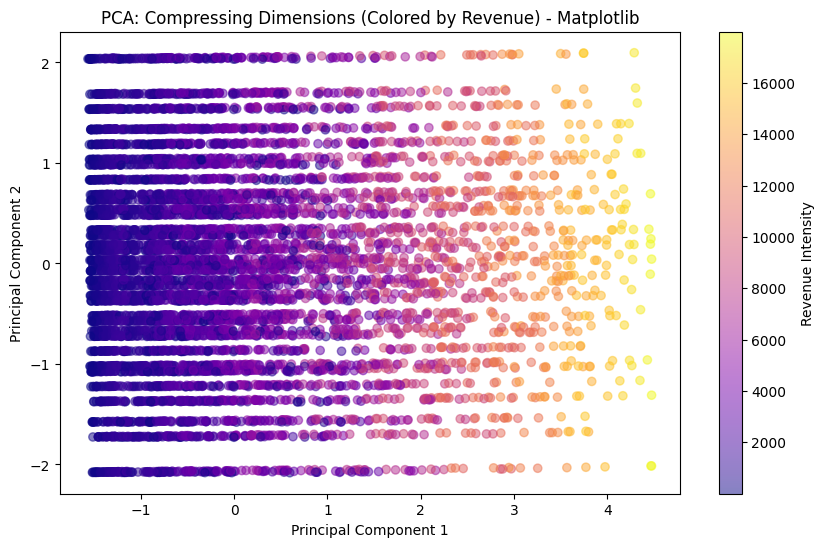

Variance explained by 2 components: 67.87%


In [18]:
X = pca_df[['Revenue', 'Quantity', 'Prod_Enc', 'Store_Enc']]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pca_df['Revenue'], cmap='plasma', alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Compressing Dimensions (Colored by Revenue) - Matplotlib")
plt.colorbar(label="Revenue Intensity")
plt.show()

print(f"Variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# --- Plotly Interactive Version ---
pca_df['PC1'] = X_pca[:, 0]
pca_df['PC2'] = X_pca[:, 1]

fig_after = px.scatter(
    pca_df, 
    x='PC1', 
    y='PC2', 
    color='Revenue',
    hover_data=['Product', 'Store', 'Quantity'],
    title="After PCA: 2D Compressed Representation (Plotly)",
    color_continuous_scale='Plasma'
)
fig_after.show()

##  Discussion Questions Preparation
Use this lab to help answer your weekly discussion questions:
-   **DQ 1 (Operational vs Analytical)**: How did the raw CSV/JSON (Operational) differ from the final `dw_df` (Analytical)?
-   **DQ 2 (Lake vs Warehouse)**: Why did we need both `data_lake/` and `data_warehouse/` directories?

--- 
## Assignment Report Checklist
Before submitting to Turnitin, ensure your report includes:
1. **Introduction and Dataset Generation**: 1-2 paragraphs describing (the dataset you chose to create and its dimensions), on how we use Numpy and random number generator to generate, create and save in csv and json and read it and standarize it.
   
2. **EDA**: Note that to be successful data scientist and the intreprter, you must start with proper visulization of data, so, do proper explanatory data analysis (EDA) on both set of drataframes from above generated files. (see shape, size, data type, info, describe, missing number of values on column, ranges, malformed data types and so on, so you would be ready for transformation and cleaning)
3.  **Transformation and Cleaning**: Perform cleaning and preprocessing, dont miss to drop and fill and make sure the data type is what you intended. Then for the roll up and drill down purposes do some transformation or some feature engineering.
4.  **Operations**: Cover every OLAP operations with proper visulization and justification. Design Start, SNowflake and fact contesllation architecture from the transformed data.
5.  **Dimensions**: Identify the dimension and display some cube and cuboids illustration.
6.  **Curse of Dimension**: Justify the curse of dimension, its impact and remedies.
7.  **Git Version Control**: Ensure you have initialized a Git repository (`git init`) and pushed your code by making a folder named `data-mining-warehouse` within your `Documents` directory. Students must show proof by providing screenshots of the Git remote link and their commit history.
8. **Screenshots**: Take clear screenshots of your Jupyter Notebook running on Kernel with your Name and supporting the operations of OLAP  the Slice, Dice, and all operations and Aggregation steps.
9. **Written Explanation**: 
    - Give an example of a Drill-Down (e.g., moving from City to Store Address).
    - Give an example of a Roll-Up (e.g., moving from Daily to Yearly totals).
    - Explain why this Data Cube view is better for a manager than a flat Excel spreadsheet.
10. **Length**: The report must be 4 to 5 pages.
11. **Citations**: At least TWO Academic Citations in APA 7 format.
